In [2]:
import scipy as sc
import numpy as np
import sympy as sp
import matplotlib as mpl
import matplotlib.pyplot as plt

0.9999999999999999


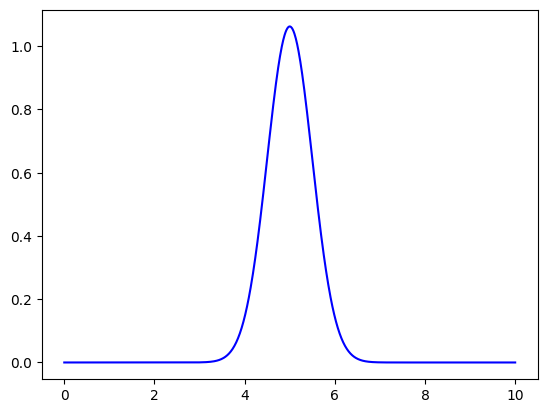

In [151]:
def psi(x, xc, o):
    return np.exp(-(x-xc)**2/(2*o**2))/(np.pi*o**2)**0.25

L = 10
N = 1000
xc = 5
sigma = 0.5
x = np.linspace(0, L, N)

def integrand(x):
     return np.abs(psi(x, xc, sigma)**2)

p, errp = sc.integrate.quad(integrand, 0, L)
plt.plot(x, psi(x, xc, sigma), c = 'blue')

print(p)

In [145]:
k = 1
def coeffIntegrand(x):
    return psi(x, xc, sigma) * np.sin(np.pi * k * x / L)

def coeffk():
    ck, err = sc.integrate.quad(coeffIntegrand, 0, L, epsrel = 1e-012)
    return ck * (2/L)**0.5
k=21
print(coeffk())

0.00258209056705191


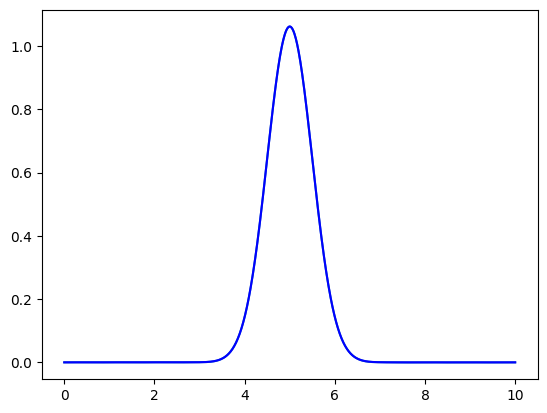

In [146]:
numIter = 21
psi_superposition = np.zeros(N)
ck = np.zeros(numIter)

for n in range(numIter):
    k = n + 1
    ck[k-1] = coeffk()
    psi_superposition = psi_superposition + (coeffk() * (2/L)**0.5 * np.sin((n+1)*np.pi*x/L))
    #print(coeffk())

plt.plot(x,psi_superposition)
plt.plot(x, psi(x, xc, sigma), c = 'blue')


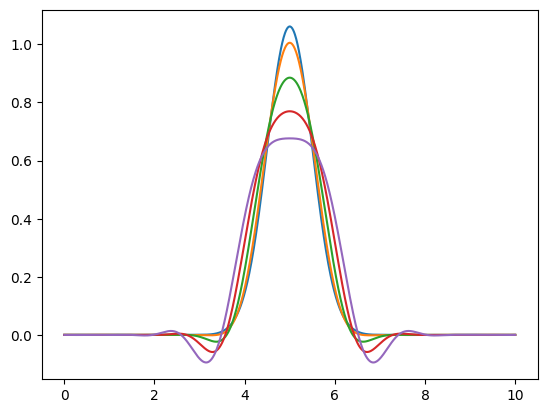

In [147]:
def Energyk(k):
    return (k*np.pi/L)**2*0.5

def psi_evolve(t, ck = ck):
    psie = np.zeros(N)

    for n in range(numIter):
        psie = psie + (ck[n] * (2/L)**0.5 * np.sin((n+1)*np.pi*x/L)) * np.exp(1j * Energyk(n+1)* t)
    return psie

plt.plot(x,np.real(psi_evolve(t=0)))
plt.plot(x,np.real(psi_evolve(t=0.1)))
plt.plot(x,np.real(psi_evolve(t=0.2)))
plt.plot(x,np.real(psi_evolve(t=0.3)))
plt.plot(x,np.real(psi_evolve(t=0.4)))

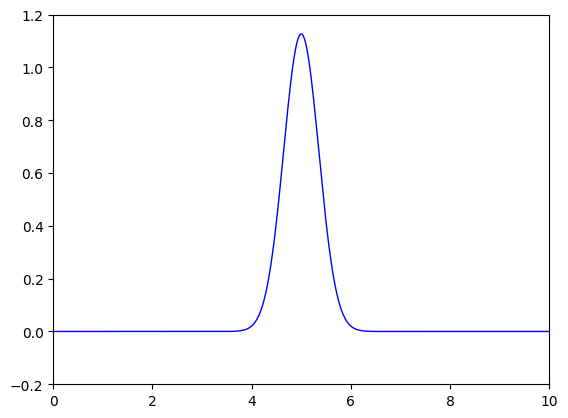

In [149]:
from matplotlib import pyplot as plt, animation

fig, ax = plt.subplots()
ax.set(xlim=(0, 10), ylim=(-0.2, 1.2))
time_text = ax.text(0.02, 0.95, '', transform=ax.transAxes)

t = np.linspace(0, 16,200)
psis = [psi_evolve(t=0)]
for n in range(len(t)-1):
   psis.append(psi_evolve(t=t[n+1]))

line, = ax.plot(x, np.abs(psis[0])**2, color='b', lw=1)

def animate(i):
   line.set_ydata(np.abs(psis[i])**2)
   time_text.set_text('Time = %0.2f' % t[i])
anim = animation.FuncAnimation(fig, animate, interval=1, frames=len(t) - 1)
plt.show()
#anim.save(filename="/Users/hasan/Python Animations/1D_Particle_in Box_Evolution.gif", writer="pillow")
